# Feature Engineering Notebook for my CTA strategy

In [ ]:
# Import packages

import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# notebooks/ and src/ are siblings after the Scripts/ reorg (cleanup.md) - signal_lib.py
# is no longer in the same folder as this notebook, so it needs to be on sys.path explicitly.
sys.path.insert(0, str(Path.cwd().parent / "src"))

from signal_lib import (
    load_price_data,
    build_momentum_features,
    binary_signal,
    continuous_signal,
    rank_signal,
    weekly_positions,
    monthly_positions,
    backtest_signal,
    performance_stats,
)

In [2]:
# Read data (shared loader - includes the Rice bad-print patch)

data = load_price_data()

open_prices  = data["open"]
high_prices  = data["high"]
low_prices   = data["low"]
close_prices = data["close"]
volume       = data["volume"]
volatility   = data["volatility"]

In [3]:
# Sanity check

print(open_prices.shape)
print(high_prices.shape)
print(low_prices.shape)
print(close_prices.shape)
print(volume.shape)

print(open_prices.columns.equals(close_prices.columns))
print(open_prices.index.equals(close_prices.index))

(6499, 38)
(6499, 38)
(6499, 38)
(6499, 38)
(6499, 38)
True
True


## Universe inclusion rule (pre-registered, CLAUDE.md Rule 1)

This notebook previously dropped Natural Gas and then all of Energy *after* observing
they hurt the Sharpe ratio (see the removed "Let's test why energy doesn't work"
section further down, kept in `deprecated/` history only). That's a look-ahead bug on
the universe itself: it uses backtest performance to decide inclusion.

The fix: a liquidity floor decided from average daily volume alone, before any signal
is backtested. Threshold = 1,000 contracts/day average volume, trailing 2 years as of
the decision date (2026-07-14) - a standard institutional minimum-liquidity screen,
independent of returns. Checked against the notebook's own energy drop: Natural Gas
(~163k ADV) and Brent (~44k ADV) are both far above this threshold and rank mid-to-high
across the whole universe - a genuine liquidity rule does **not** support dropping them.
Energy stays in.

In [4]:
# ==========================================
# Universe filter: ADV liquidity floor
# ==========================================

ADV_WINDOW_START = "2024-07-14"  # trailing 2 years as of the decision date
ADV_THRESHOLD = 1000              # contracts/day, institutional minimum-liquidity screen

adv = volume.loc[ADV_WINDOW_START:].mean()
excluded_assets = adv[adv < ADV_THRESHOLD].index.tolist()
included_assets = adv[adv >= ADV_THRESHOLD].index.tolist()

print(f"Excluded (ADV < {ADV_THRESHOLD}): {excluded_assets}")
print(f"Universe: {len(included_assets)} of {len(adv)} assets")

open_prices  = open_prices[included_assets]
high_prices  = high_prices[included_assets]
low_prices   = low_prices[included_assets]
close_prices = close_prices[included_assets]
volume       = volume[included_assets]
volatility   = volatility.loc[:, volatility.columns.get_level_values(1).isin(included_assets)]

Excluded (ADV < 1000): ['Platinum', 'Palladium', 'Rice', 'Oats', 'OrangeJuice']
Universe: 33 of 38 assets


In [5]:
# Extract volatility horizons

yz_vol_21 = volatility["yz_vol_21"]
yz_vol_63 = volatility["yz_vol_63"]
yz_vol_126 = volatility["yz_vol_126"]
yz_vol_252 = volatility["yz_vol_252"]

## Let's think about what we want to do: A preliminary feature set is the following

* Momentum: 21, 63, 126, 252
* Moving Average Features: 50, 100, 200
* Trend t-stat: Use slope over 63, 126 and 252 days
* Donchian breakouts: 20, 60, 120 days
* Volatility: 21, 63, 252, try Parkinson, Yang-Zhang
* Any RV crap I'll think about

### Time-Series Momentum Alphas

As a first step, try to look at multiple momentum horizons with our without lookback periods. All features make it.

In [6]:
# ==========================================
# Momentum Features (raw + skip variants)
# Skip period scales from the classical 12-1
# specification: skip = lookback * (21 / 252)
# ==========================================

lookbacks = [21, 63, 126, 252]

momentum = build_momentum_features(close_prices, lookbacks)


# ==========================================
# Individual DataFrames
# ==========================================

mom_21 = momentum["mom_21"]
mom_63 = momentum["mom_63"]
mom_126 = momentum["mom_126"]
mom_252 = momentum["mom_252"]

mom_21_skip = momentum["mom_21_skip"]
mom_63_skip = momentum["mom_63_skip"]
mom_126_skip = momentum["mom_126_skip"]
mom_252_skip = momentum["mom_252_skip"]


# ==========================================
# Combined Feature Store
# ==========================================

features = pd.concat(momentum, axis=1)

Now we transition from features to signals. We will evaluate 3 distinct ways, each with their pros and cons:

* Binary: Only show direction (+1, 0, -1). Very robust, but throws away information
* Continuous: For time series momentum, we use cross-sectional z-scores
* Ranked: Robust, but loses valuable absolute information

In [7]:
# Generate binary signals

binary_signals = {
    name: binary_signal(feature)
    for name, feature in momentum.items()
}

In [8]:
# Generate continuous signals, which are the vol normalized TSMOM from Ooi - Pedersen etc

continuous_signals = {
    "mom_21": continuous_signal(mom_21, yz_vol_21),
    "mom_63": continuous_signal(mom_63, yz_vol_63),
    "mom_126": continuous_signal(mom_126, yz_vol_126),
    "mom_252": continuous_signal(mom_252, yz_vol_252),

    "mom_21_skip": continuous_signal(mom_21_skip, yz_vol_21),
    "mom_63_skip": continuous_signal(mom_63_skip, yz_vol_63),
    "mom_126_skip": continuous_signal(mom_126_skip, yz_vol_126),
    "mom_252_skip": continuous_signal(mom_252_skip, yz_vol_252),
}

In [9]:
# Generate ranked singals, which means convert features into percentile ranks: We also center ranked signals around 0

rank_signals = {
    name: rank_signal(feature)
    for name, feature in momentum.items()
}

Now organize

In [10]:
signals = {
    "binary": binary_signals,
    "continuous": continuous_signals,
    "rank": rank_signals
}

At this stage, the feature engineering process is complete and momentum features have been transformed into trading signals. The objective of the next stage is to determine whether these signals contain predictive information and whether they can generate profitable trading strategies. Importantly, this stage focuses on signal evaluation, not portfolio optimization. The goal is to understand the behavior of individual signals before combining them into a larger portfolio.

## Research Questions

The initial backtests seek to answer the following questions:

1. Which momentum horizon performs best?
   - 21-day
   - 63-day
   - 126-day
   - 252-day

2. Does skipping recent returns improve performance?

3. Do continuous signals outperform binary signals?

4. How sensitive are results to rebalancing frequency?

5. Which signals deserve inclusion in a later multi-alpha portfolio?

Only after these questions are answered will more advanced portfolio construction techniques such as volatility targeting, risk budgeting, covariance estimation, and optimization be introduced.

In [11]:
# ==========================================
# Returns
#
# weekly_positions, monthly_positions, and
# backtest_signal are imported from signal_lib
# (Phase 1 extraction - this notebook used to
# have two slightly different backtest_signal
# definitions inline; now there is exactly one,
# with an explicit returns_data parameter).
# ==========================================

returns = close_prices.pct_change(fill_method = None)

## Train / held-out split (pre-registered, CLAUDE.md Rule 1)

The comparisons below (binary vs. continuous vs. rank, which horizon performs best)
are exactly the kind of conclusion that previously got drawn on the full sample and
then re-tested by iterating against it. From here on they run on **train data only**;
a single held-out check happens once, at the very end, without further tuning
afterward.

Split chosen before looking at any performance it affects: ~75/25 by calendar time.
2020+ is held out on purpose rather than folded into training - it usefully contains a
real stress period (COVID), so the held-out check isn't just quiet, easy markets.

In [12]:
TRAIN_END = "2019-12-31"

returns_train = returns.loc[:TRAIN_END]
returns_holdout = returns.loc[TRAIN_END:].iloc[1:]  # exclude the boundary date itself

print(f"Train:    {returns_train.index.min().date()} -> {returns_train.index.max().date()} ({len(returns_train)} days)")
print(f"Held-out: {returns_holdout.index.min().date()} -> {returns_holdout.index.max().date()} ({len(returns_holdout)} days)")

Train:    2000-08-23 -> 2019-12-31 (4857 days)
Held-out: 2020-01-02 -> 2026-07-14 (1642 days)


In [13]:
# ==========================================
# Binary Signals (train only - see split above)
# ==========================================

binary_weekly = {}
binary_monthly = {}

for name, signal in signals["binary"].items():

    signal_train = signal.loc[:TRAIN_END]

    binary_weekly[name] = backtest_signal(
        signal_train,
        returns_train,
        frequency="weekly"
    )

    binary_monthly[name] = backtest_signal(
        signal_train,
        returns_train,
        frequency="monthly"
    )

In [14]:
# ==========================================
# Continuous Signals (train only - see split above)
# ==========================================

continuous_weekly = {}
continuous_monthly = {}

for name, signal in signals["continuous"].items():

    signal_train = signal.loc[:TRAIN_END]

    continuous_weekly[name] = backtest_signal(
        signal_train,
        returns_train,
        frequency="weekly"
    )

    continuous_monthly[name] = backtest_signal(
        signal_train,
        returns_train,
        frequency="monthly"
    )

In [15]:
# Rank Signals (train only - see split above)

rank_weekly = {}
rank_monthly = {}

for name, signal in signals["rank"].items():

    signal_train = signal.loc[:TRAIN_END]

    rank_weekly[name] = backtest_signal(
        signal_train,
        returns_train,
        frequency="weekly"
    )

    rank_monthly[name] = backtest_signal(
        signal_train,
        returns_train,
        frequency="monthly"
    )

In [16]:
binary_monthly_summary = pd.DataFrame({
    name: performance_stats(ret)
    for name, ret in binary_monthly.items()
}).T

binary_monthly_summary.sort_values(
    "Sharpe",
    ascending=False
)

,Ann Return,Ann Vol,Sharpe,Max DD
mom_63_skip,-0.009324,0.107651,-0.086617,-0.374277
mom_252_skip,-0.010735,0.110769,-0.096915,-0.390653
mom_126_skip,-0.013098,0.106539,-0.122938,-0.373520
mom_126,-0.013411,0.106353,-0.126099,-0.358777
mom_252,-0.017925,0.112796,-0.158917,-0.386700
mom_63,-0.018034,0.107301,-0.168065,-0.399460
mom_21,-0.023421,0.104801,-0.223484,-0.501960
mom_21_skip,-0.024699,0.104900,-0.235448,-0.455245


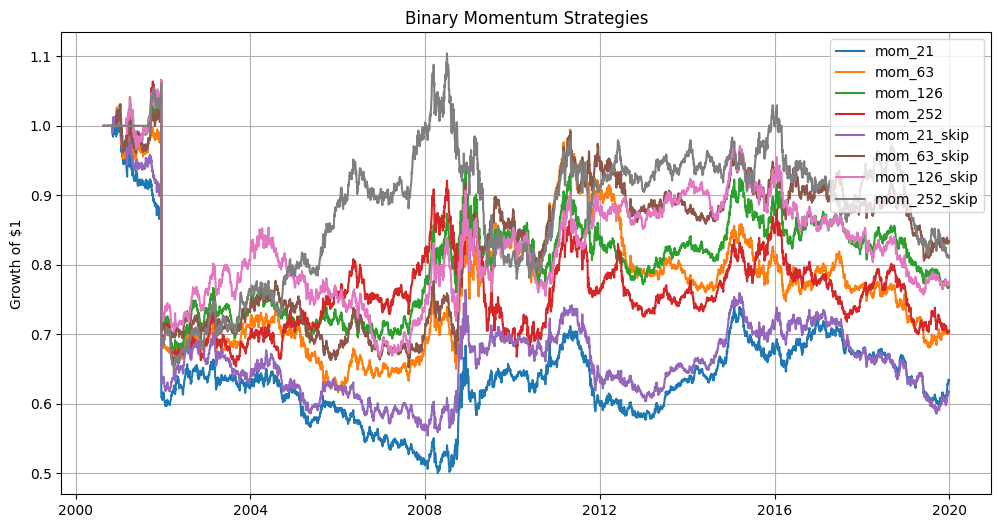

In [17]:
plt.figure(figsize=(12, 6))

for name, ret in binary_monthly.items():

    equity_curve = (1 + ret).cumprod()

    plt.plot(
        equity_curve.index,
        equity_curve.values,
        label=name
    )

plt.title("Binary Momentum Strategies")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.show()

## Takeaway Number 1: Binary momentum signals are a disaster in this universe. All 8 binary variants are negative Sharpe on train data - consistent under the ADV-filtered universe and train-only split. And generally, this kind of makes sense, because it does not quantify the signal. It throws a lot of information out. And this makes stuff not work.

In [18]:
continuous_monthly_summary = pd.DataFrame({
    name: performance_stats(ret)
    for name, ret in continuous_monthly.items()
}).T

continuous_monthly_summary.sort_values(
    "Sharpe",
    ascending=False
)

,Ann Return,Ann Vol,Sharpe,Max DD
mom_126_skip,0.006075,0.109690,0.055383,-0.254648
mom_21_skip,-0.009057,0.103460,-0.087538,-0.351037
mom_63_skip,-0.010623,0.119468,-0.088915,-0.401754
mom_252_skip,-0.009924,0.104216,-0.095229,-0.446584
mom_126,-0.014185,0.121052,-0.117180,-0.373049
mom_252,-0.015723,0.106433,-0.147724,-0.409286
mom_21,-0.018687,0.109369,-0.170859,-0.457133
mom_63,-0.021630,0.124823,-0.173287,-0.466049


## Takeaway Number 2 (revised under train-only/ADV-filtered methodology): continuous still clearly beats binary - every continuous variant outperforms its binary counterpart. But "longer horizon is better" is weaker than the original full-sample read suggested: on train data, only `mom_126_skip` is positive Sharpe; `mom_252_skip` (the previous hardcoded pick) is actually negative in-sample. Mid-horizon, skip-adjusted momentum is the standout here, not simply "longest wins." Short horizons (21-day) are still clearly the worst, consistent with the original take.

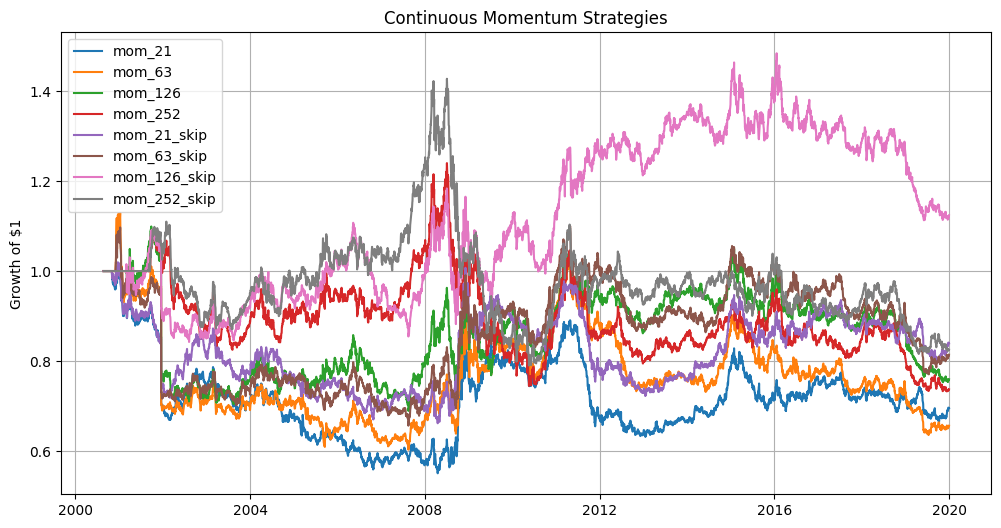

In [19]:
plt.figure(figsize=(12, 6))

for name, ret in continuous_monthly.items():

    equity_curve = (1 + ret).cumprod()

    plt.plot(
        equity_curve.index,
        equity_curve.values,
        label=name
    )

plt.title("Continuous Momentum Strategies")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.show()

---

---

Now let's take a look at our best performing signal.

In [20]:
# Best-performing signal, chosen by train-period Sharpe (not hardcoded - under the
# corrected ADV-filtered/train-only methodology this is no longer mom_252_skip, which
# was the previous hardcoded pick but is actually negative Sharpe in-sample now).

best_name = continuous_monthly_summary.sort_values("Sharpe", ascending=False).index[0]
best = continuous_monthly[best_name]

print(f"Best signal (train Sharpe): {best_name}")

Best signal (train Sharpe): mom_126_skip


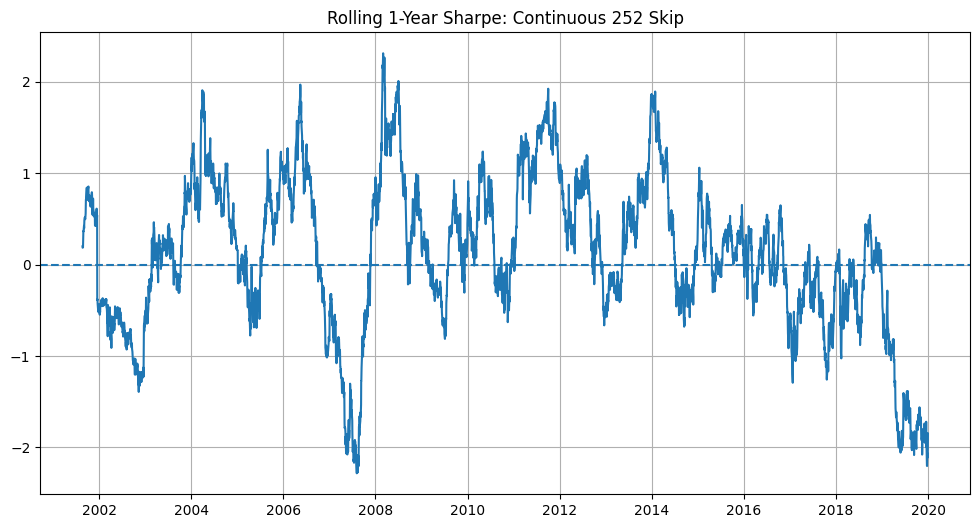

In [21]:
rolling_sharpe = (
    best.rolling(252).mean()
    /
    best.rolling(252).std()
) * np.sqrt(252)

plt.figure(figsize=(12, 6))

plt.plot(
    rolling_sharpe.index,
    rolling_sharpe
)

plt.title("Rolling 1-Year Sharpe: Continuous 252 Skip")
plt.axhline(0, linestyle="--")
plt.grid(True)

plt.show()

Now let's look at the asset level performance of the strategy.

In [22]:
signal = signals["continuous"][best_name]

positions = monthly_positions(signal)

positions = positions.shift(1)

positions = positions.div(
    positions.abs().sum(axis=1),
    axis=0
)

positions = positions.fillna(0)

In [23]:
asset_pnl = (
    positions
    * returns
).sum()

In [24]:
asset_pnl = asset_pnl.sort_values()

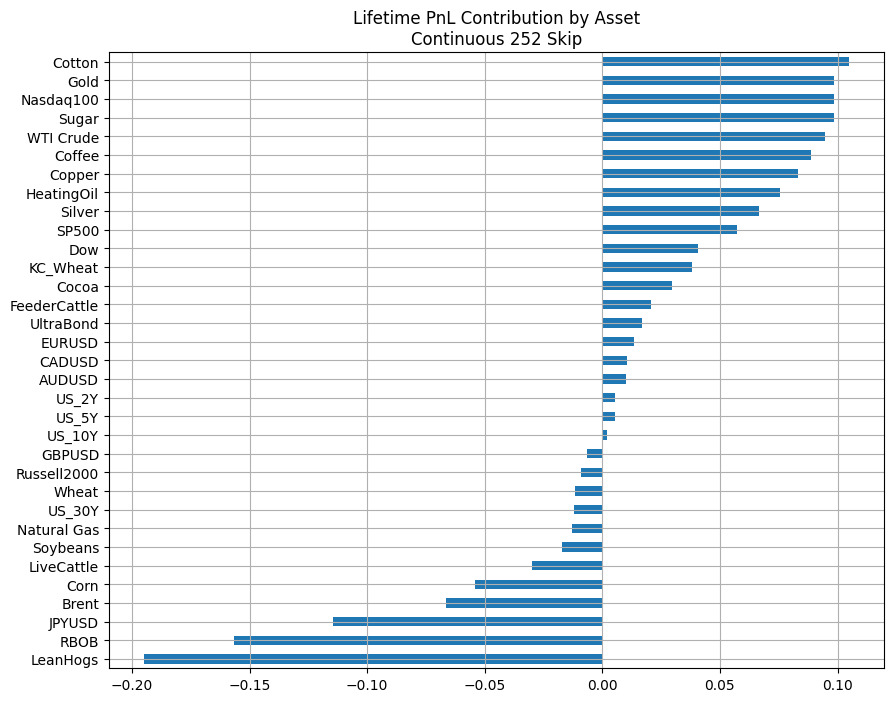

In [25]:
plt.figure(figsize=(10, 8))

asset_pnl.plot(kind="barh")

plt.title(
    "Lifetime PnL Contribution by Asset\nContinuous 252 Skip"
)

plt.grid(True)

plt.show()

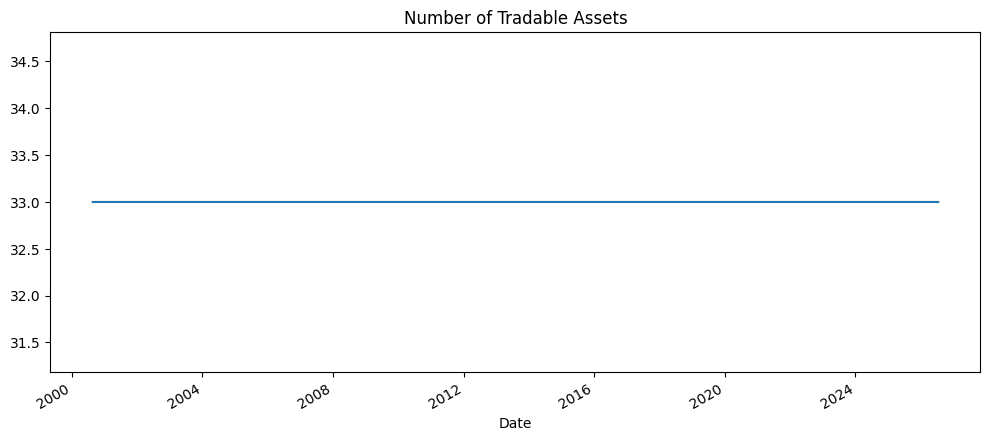

In [26]:
active_assets = (
    positions.notna()
    .sum(axis=1)
)

active_assets.plot(figsize=(12,5))
plt.title("Number of Tradable Assets")
plt.show()

In [27]:
# ==========================================
# Forecast Correlations
# ==========================================

signal_corr = pd.DataFrame({
    "21_skip": signals["continuous"]["mom_21_skip"].stack(),
    "63_skip": signals["continuous"]["mom_63_skip"].stack(),
    "126_skip": signals["continuous"]["mom_126_skip"].stack(),
    "252_skip": signals["continuous"]["mom_252_skip"].stack(),
}).corr()

signal_corr

,21_skip,63_skip,126_skip,252_skip
21_skip,1.000000,0.484087,0.243348,0.032987
63_skip,0.484087,1.000000,0.637725,0.361767
126_skip,0.243348,0.637725,1.000000,0.630089
252_skip,0.032987,0.361767,0.630089,1.000000


Let's verify our universe is what we thought it would be.

In [28]:
assert set(close_prices.columns) == set(included_assets)
assert len(close_prices.columns) == 33
assert not any(a in close_prices.columns for a in excluded_assets)

print(f"Universe: {len(close_prices.columns)} assets")
print(sorted(close_prices.columns.tolist()))

Universe: 33 assets
['AUDUSD', 'Brent', 'CADUSD', 'Cocoa', 'Coffee', 'Copper', 'Corn', 'Cotton', 'Dow', 'EURUSD', 'FeederCattle', 'GBPUSD', 'Gold', 'HeatingOil', 'JPYUSD', 'KC_Wheat', 'LeanHogs', 'LiveCattle', 'Nasdaq100', 'Natural Gas', 'RBOB', 'Russell2000', 'SP500', 'Silver', 'Soybeans', 'Sugar', 'US_10Y', 'US_2Y', 'US_30Y', 'US_5Y', 'UltraBond', 'WTI Crude', 'Wheat']


## Held-out check (once, no further tuning after this)

The signal selected by train-period Sharpe above (`best_name`) is carried forward
unchanged. This is the single held-out evaluation on 2020+ data, per the split defined
earlier - not a search over alternatives.

In [29]:
holdout_signal = signals["continuous"][best_name].loc[TRAIN_END:].iloc[1:]

ret_holdout = backtest_signal(
    holdout_signal,
    returns_holdout,
    frequency="monthly"
)

held_out_stats = performance_stats(ret_holdout)
train_stats = performance_stats(continuous_monthly[best_name])

pd.DataFrame({
    "Train (<=2019)": train_stats,
    "Held-out (2020+)": held_out_stats,
})

,Train (<=2019),Held-out (2020+)
Ann Return,0.006075,0.016996
Ann Vol,0.109690,0.132612
Sharpe,0.055383,0.128164
Max DD,-0.254648,-0.242619
